In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from multiprocessing import Pool
import glob

In [4]:
def symmetric_matrix(theta):
    # size of symmetric matrix
    n = int((np.sqrt(1 + 8 * len(theta)) - 1) / 2)
    if len(theta) != n * (n + 1) // 2:
        raise ValueError("Size of theta is invalid for a symmetric matrix")
    # init matrix by generating triangles and then diagonal
    matrix = np.zeros((n, n))
    triu_indices = np.triu_indices(n)
    matrix[triu_indices] = theta
    matrix = matrix + matrix.T - np.diag(np.diag(matrix))
    return np.matrix(matrix)

def extract_theta(symmetric_matrix):
    # extract and flatten to correct shape
    triu_indices = np.triu_indices(symmetric_matrix.shape[0])
    theta = symmetric_matrix[triu_indices]
    return np.array(theta).flatten()

In [5]:
def meta_int(X, t, betat, gamma, mu, Na):
    # solving odes for system
    S = X[:3]
    I = X[3:6]
    Theta = X[6:]
    beta = betat(t)
    Inf = (beta @ I) / Na

    dS = -Inf*S + (Na-S)*mu
    dI = Inf*S - (gamma+mu)*I
   
    # solving Lyapunov equation for covariance
    S = S/Na
    I = I/Na
    J_ss = np.diag([-mu-Inf[0],-mu-Inf[1],-mu-Inf[2]])
    J_si = -beta * S[:, np.newaxis]
    J_is = np.diag([Inf[0],Inf[1],Inf[2]])
    J_ii = -(mu+gamma)*np.eye(3) + beta * S[:, np.newaxis]
    A = np.block([[J_ss,J_si],[J_is,J_ii]])

    B_ss = np.diag([mu*(1-S[0])+S[0]*Inf[0],mu*(1-S[1])+S[1]*Inf[1],mu*(1-S[2])+S[2]*Inf[2]])
    B_si = np.diag([-mu*I[0]-S[0]*Inf[0],-mu*I[1]-S[1]*Inf[1],-mu*S[2]-S[2]*Inf[2]])
    B_ii = np.diag([(gamma+mu)*I[0]+S[0]*Inf[0],(gamma+mu)*I[1]+S[1]*Inf[1],(gamma+mu)*I[2]+S[2]*Inf[2]])
    B = np.block([[B_ss,B_si],[B_si,B_ii]])

    Θ = symmetric_matrix(Theta)
    K = A*Θ+Θ*A.transpose()+B
    return np.concatenate([dS,dI,extract_theta(K)])

$R_0=1/(\gamma+\mu)*\rho(\beta)$

In [6]:
# system parameters
gamma = 0.1
mu = 1/(80*365)
b_w = 0.231
b_b = 0.12
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
np.max(np.linalg.eigvals(beta_matrix))/(gamma+mu)

4.005684465099393

In [7]:
def analyze_epidemic_data(folder_name, betat, ts, gamma, mu, N_population, Si, Ii, etol):
    # compute theoretical results
    theory = odeint(meta_int, np.append(np.hstack((Si,Ii)), np.zeros(21)), 
                   ts, args=(betat,gamma,mu,N_population))
    cov = [symmetric_matrix(theory[i,6:])[3:,3:] for i in range(len(ts))]
    eigvals = [np.max(np.linalg.eigvalsh(cov[i])) for i in range(len(ts))]
    norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i])) 
                   for i in range(len(ts))]
    eigvec = np.array([np.linalg.eigh(cov[i])[1][:,np.argmax(np.linalg.eigh(cov[i])[0])].getA1() 
                      for i in range(len(ts))])
    Reff = [1/(N_population*(gamma+mu))*np.max(np.linalg.eigvals(theory[i,:3]*betat(ts[i]))) 
            for i in range(len(ts))]
    crossings = np.where(np.abs(np.array(Reff) - 1) <= etol)[0]
    if len(crossings) > 1:
        if folder_name == 'newvar':
            crossings = [crossings[2],crossings[-2]]
        else:
            crossings = crossings[0]

    # get simulation results
    file_paths = sorted(glob.glob(f"Cluster_Results/{folder_name}/I*.npy"))
    data_list = [np.load(fp) for fp in file_paths]
    data = np.stack(data_list, axis=0)[:-1]
    data = data.reshape(-1, 3, 1001)
    mean_per_time = data.mean(axis=0)
    I_lb = np.quantile(data,q=[0.25,0.975],axis=0)
    mean_subtracted = (data - mean_per_time)/np.sqrt(N_population)
    covariances = np.zeros((3, 3, 1001))
    for t in range(1001):
        snapshot = mean_subtracted[:, :, t]
        covariances[:, :, t] = np.cov(snapshot, rowvar=False)
    sim_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
    sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/
                       np.linalg.norm(np.linalg.eigvalsh(covariances[:,:,i])) for i in range(len(ts))]
    sim_eigvec = np.array([np.linalg.eigh(covariances[:,:,i])[1][:,np.argmax(np.linalg.eigh(covariances[:,:,i])[0])] 
                          for i in range(len(ts))])

    # get simulation Reff
    file_paths = sorted(glob.glob(f"Cluster_Results/{folder_name}/R*.npy"))
    data_list = [np.load(fp) for fp in file_paths]
    data = np.stack(data_list, axis=0)[:-1]
    data = data.reshape(-1, 3, 1001)
    beta_matrices = np.array([betat(t) for t in ts])
    scaling_factor = 1/(N_population*(gamma+mu))
    eigvals_array = np.zeros((len(data), len(ts)))
    for j in range(len(ts)):
        sim_data = data[:,:,j]
        eigvals_array[:,j] = np.max(np.linalg.eigvals(sim_data[:,:,None] * beta_matrices[j]), axis=1)
    eigvals_array *= scaling_factor
    Reff_sims = np.mean(eigvals_array, axis=0)
    Reff_lb = np.quantile(eigvals_array, q=[0.25,0.975], axis=0)

    return {
        'theory': theory,
        'eigvals': eigvals,
        'norm_eigvals': norm_eigvals,
        'eigvec': eigvec,
        'Reff': Reff,
        'crossings': crossings,
        'mean_per_time': mean_per_time,
        'I_lb': I_lb,
        'sim_eigvals': sim_eigvals,
        'sim_norm_eigvals': sim_norm_eigvals,
        'sim_eigvec': sim_eigvec,
        'Reff_sims': Reff_sims,
        'Reff_lb': Reff_lb
    }


In [25]:
def plot_epidemic_results_single(results, ts, plot_title, npi_time=None, save_path=None, legend=True, mini_loc = 'center right'):
    fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(10,20), sharex=True)
    linestyles_mean = ['solid', (0, (5, 7.5)), 'dotted']
    linestyles = ['solid', 'dashed', 'dotted']
    colors = ['#E69F00', '#56B4E9', '#009E73']
    
    # create twin axes for vertical lines
    twin_axes = []
    for i in range(len(axs)):
        ax_twin = axs[i].twinx()
        twin_axes.append(ax_twin)
        ax_twin.set_ylim(0, 1)
        ax_twin.set_yticks([])
        ax_twin.vlines(ts[results['crossings']], ymin=0, ymax=1,
                      linestyles='--', colors='k')
        if npi_time is not None:
            ax_twin.vlines(npi_time, ymin=0, ymax=1, linestyles='-',
                         colors='k', label=plot_title)
    
    # plot ode and sim results and reff
    for i in range(3):
        axs[0].plot(ts, results['theory'][:len(ts),i+3], linestyle=linestyles_mean[i],
                    color=colors[i], label=f'Theory - City {i+1}', linewidth=2)
        axs[0].plot(ts, results['mean_per_time'][i,:len(ts)], linestyle=linestyles[i],
                    color=colors[i], label=f'Simulation - City {i+1}', linewidth=1)
        axs[0].fill_between(ts, results['I_lb'][0,i][:len(ts)], results['I_lb'][1,i][:len(ts)],
                           color=colors[i], alpha=0.2)
    axs[1].plot(ts, results['Reff'][:len(ts)], label='Theory', linewidth=2)
    axs[1].plot(ts, results['Reff_sims'][:len(ts)], label='Simulation',linestyle='--')
    axs[1].fill_between(ts, results['Reff_lb'][0][:len(ts)], results['Reff_lb'][1][:len(ts)], alpha=0.2)
    
    # plot signals
    axs[2].plot(ts, results['eigvals'][:len(ts)], label='Theory', linewidth=2)
    axs[2].plot(ts, results['sim_eigvals'][:len(ts)], label='Simulation',linestyle='--')
    axs[3].plot(ts, results['norm_eigvals'][:len(ts)], label='Theory', linewidth=2)
    axs[3].plot(ts, results['sim_norm_eigvals'][:len(ts)], label='Simulation',linestyle='--')
    for i in range(3):
        axs[4].plot(ts, np.abs(results['eigvec'][:len(ts),i]), linestyle=linestyles_mean[i],
                    color=colors[i], label=f'Theory - City {i+1}', linewidth=2)
        axs[4].plot(ts, np.abs(results['sim_eigvec'][:len(ts),i]), linestyle=linestyles[i],
                    color=colors[i], label=f'Simulation - City {i+1}', linewidth=1)
    
    # set labels anf format axes
    axs[0].set_ylabel('Number of people',fontsize=16)
    axs[1].set_ylabel(r'$R_t$',fontsize=16)
    axs[2].set_ylabel(r'$\lambda_1$',fontsize=16)
    axs[3].set_ylabel('Normalised Eigenvalue',fontsize=16)
    axs[4].set_ylabel('Absolute Dom. Eigenvector',fontsize=16)
    axs[4].set_xlabel('Time (days)',fontsize=16)

    for i in range(len(axs)):
        axs[i].patch.set_alpha(0.0)
        axs[i].set_zorder(twin_axes[i].get_zorder()+1)
        if legend:
            leg = axs[i].legend(fontsize=12, framealpha=1)
            leg.set_zorder(1000)
            if i == 0 and npi_time is not None:
                leg_twin = twin_axes[i].legend(loc=mini_loc,fontsize=12)
                leg_twin.set_zorder(1000)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.show()

## Constant $\beta$

/tmp/ipykernel_17822/3158438108.py:7: RuntimeWarning: invalid value encountered in scalar divide
  norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i]))
/tmp/ipykernel_17822/3158438108.py:33: RuntimeWarning: invalid value encountered in scalar divide
  sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/


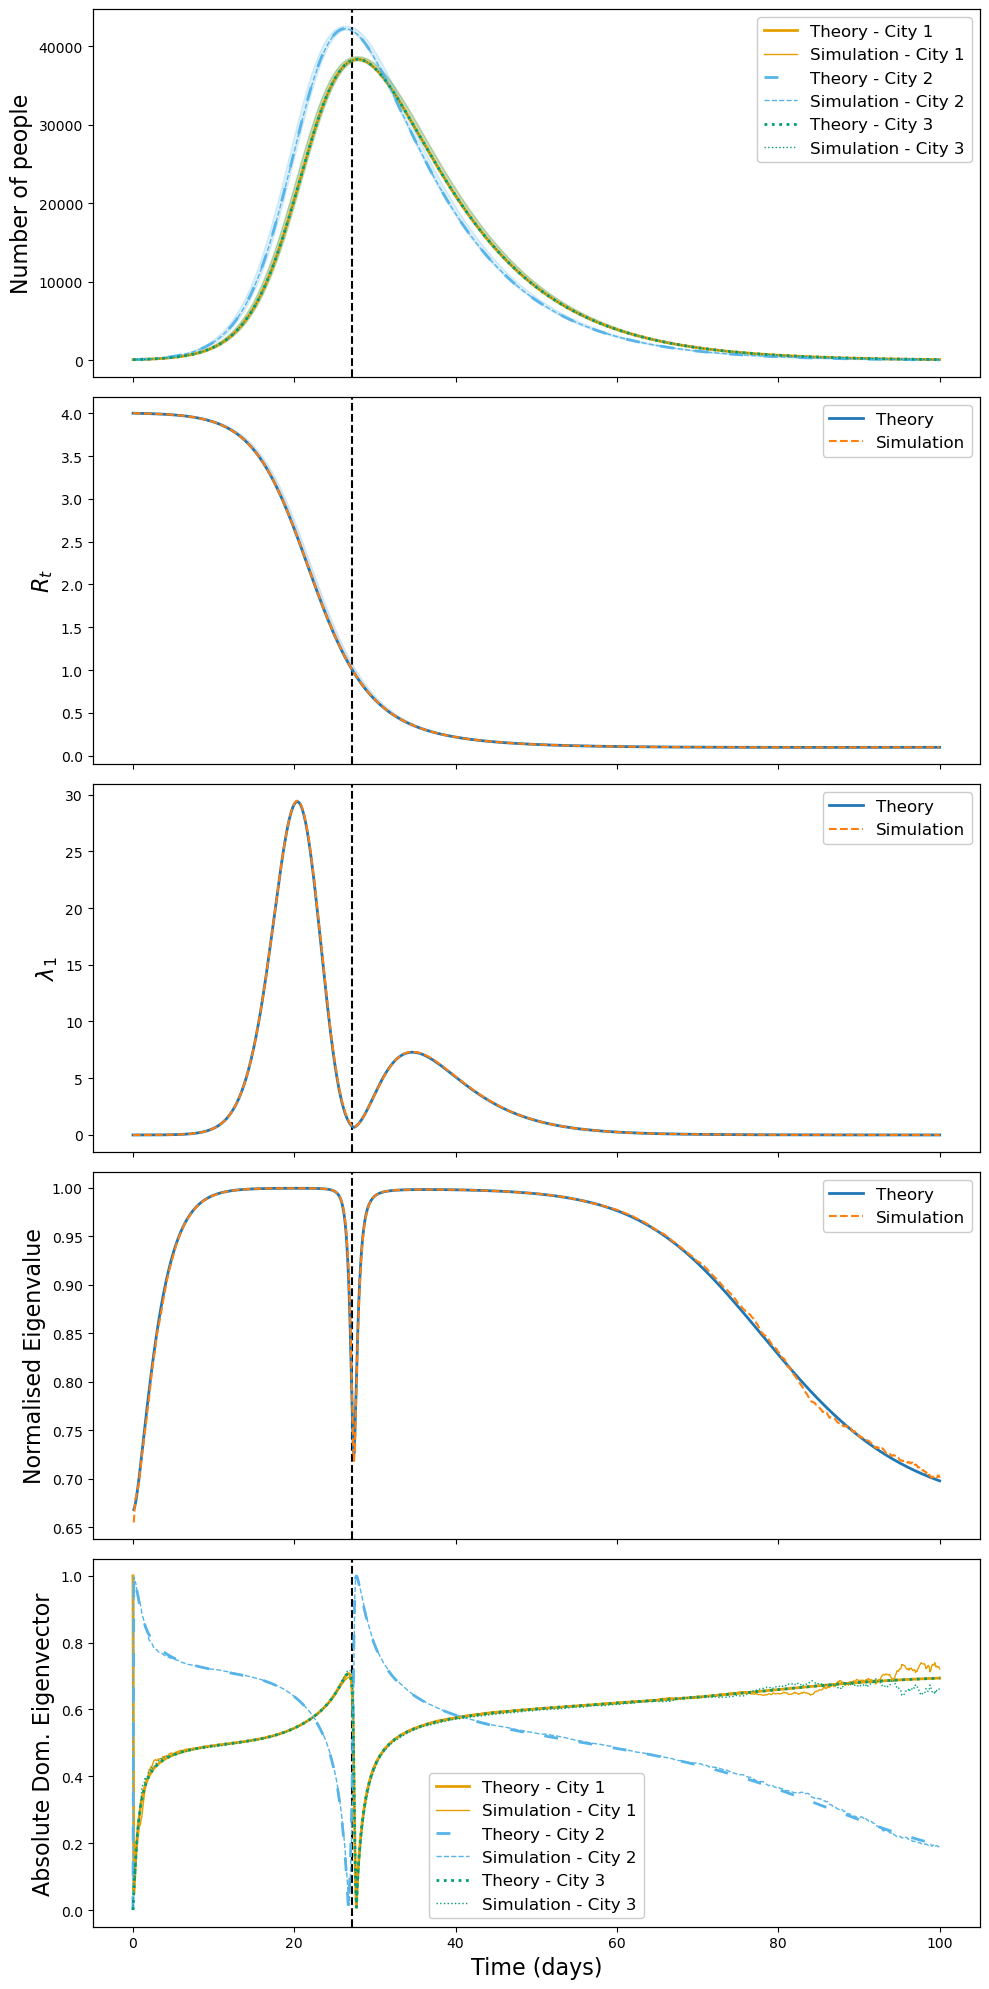

In [17]:
# parameters
N_cities = 3
T_max = 100
b_w = 0.231
b_b = 0.12
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
gamma = 0.1
mu = 1/(80*365)
N_population = 100000

Ii = np.array([100,100,100])
Si = N_population - Ii

betat = lambda t: beta_matrix
days = np.arange(0,101,1)
ts = np.arange(0,100.1,0.1)
results_constant = analyze_epidemic_data('constant', betat, ts, gamma, mu, N_population, Si, Ii, 0.005)
plot_epidemic_results_single(results_constant, ts, 'Constant beta', save_path='Figures/cst_theory.pdf')

## Just b[1,1], full epidemic

/tmp/ipykernel_17822/3158438108.py:7: RuntimeWarning: invalid value encountered in scalar divide
  norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i]))
/tmp/ipykernel_17822/3158438108.py:33: RuntimeWarning: invalid value encountered in scalar divide
  sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/


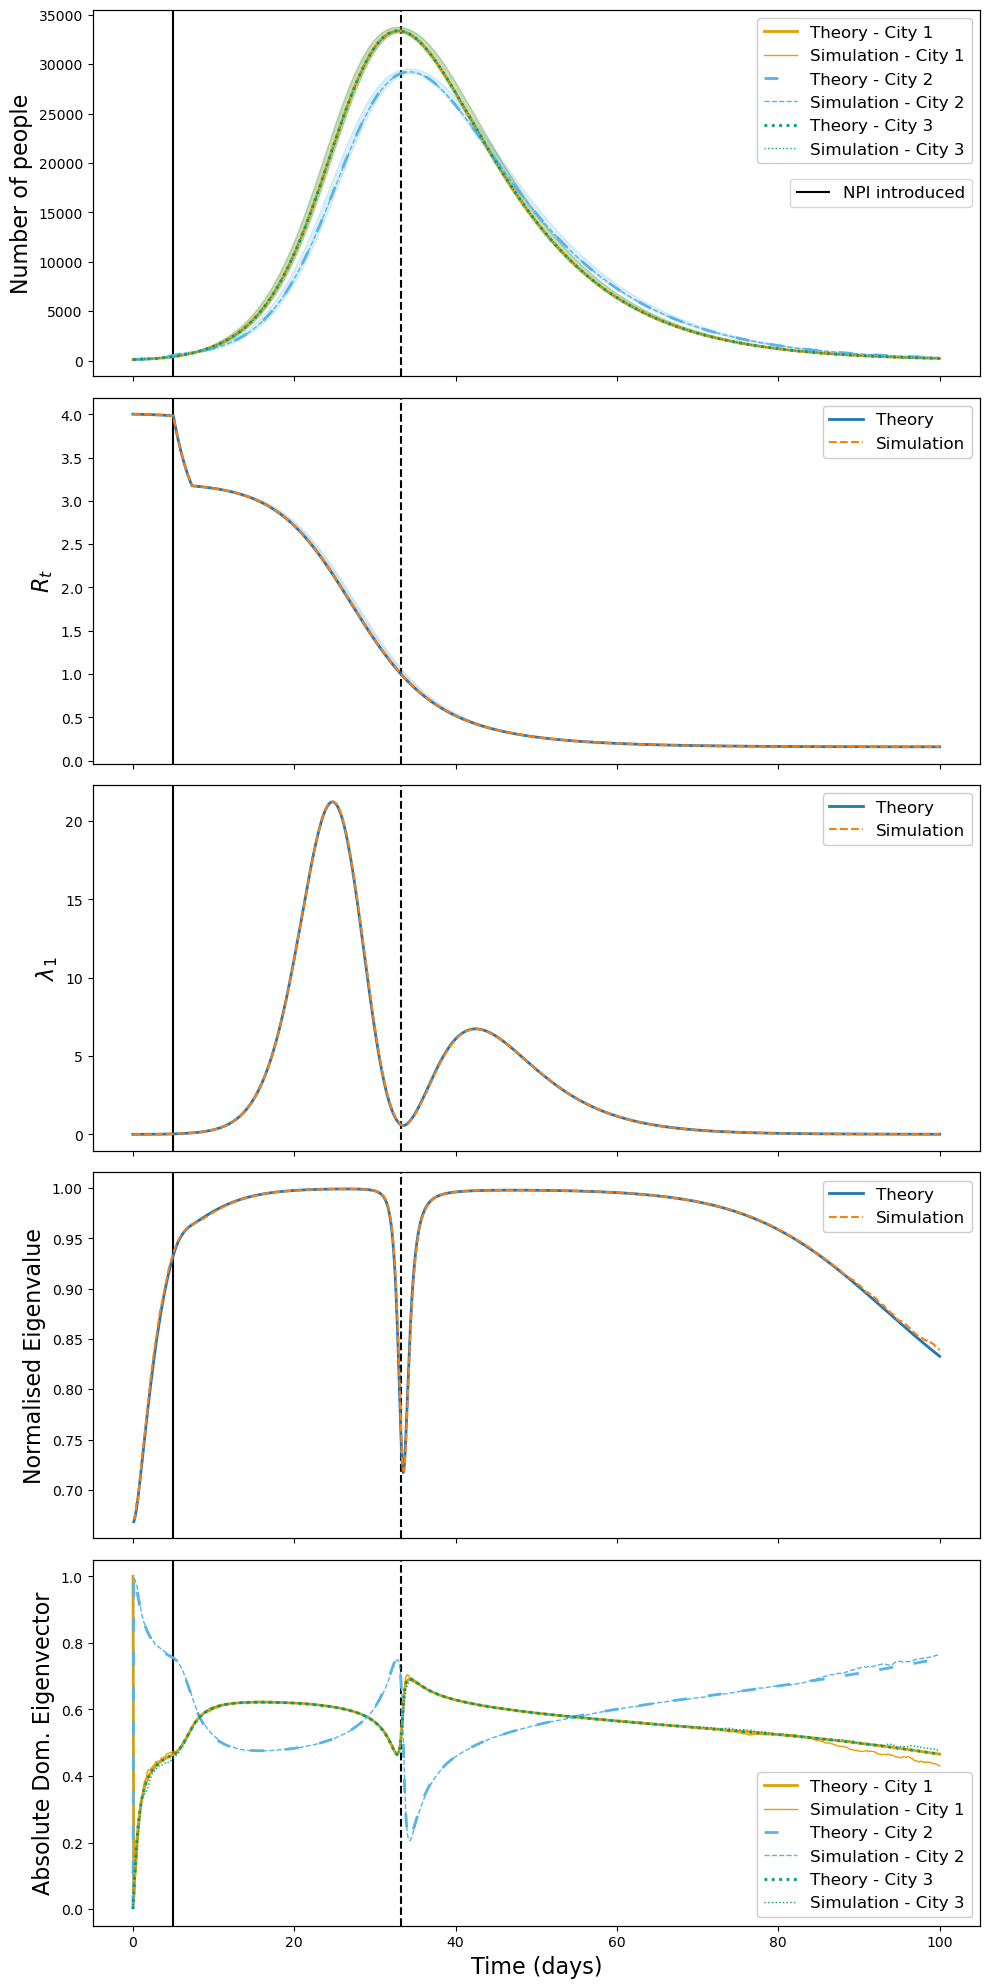

In [18]:
def betat(t):
    if t < 5:
        return beta_matrix
    else:
        temp = np.diag([0,1,0])
        return beta_matrix - 0.1*(t-5)*temp if (beta_matrix - 0.1*(t-5)*temp >= 0).all() else beta_matrix - np.diag([0,beta_matrix[1,1],0])
results_incity = analyze_epidemic_data('indec', betat, ts, gamma, mu, N_population, Si, Ii, 0.005)
plot_epidemic_results_single(results_incity, ts, 'NPI introduced', npi_time=5, save_path='Figures/in_city_theory.pdf')

## Between cities

/tmp/ipykernel_17822/3158438108.py:7: RuntimeWarning: invalid value encountered in scalar divide
  norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i]))
/tmp/ipykernel_17822/3158438108.py:33: RuntimeWarning: invalid value encountered in scalar divide
  sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/


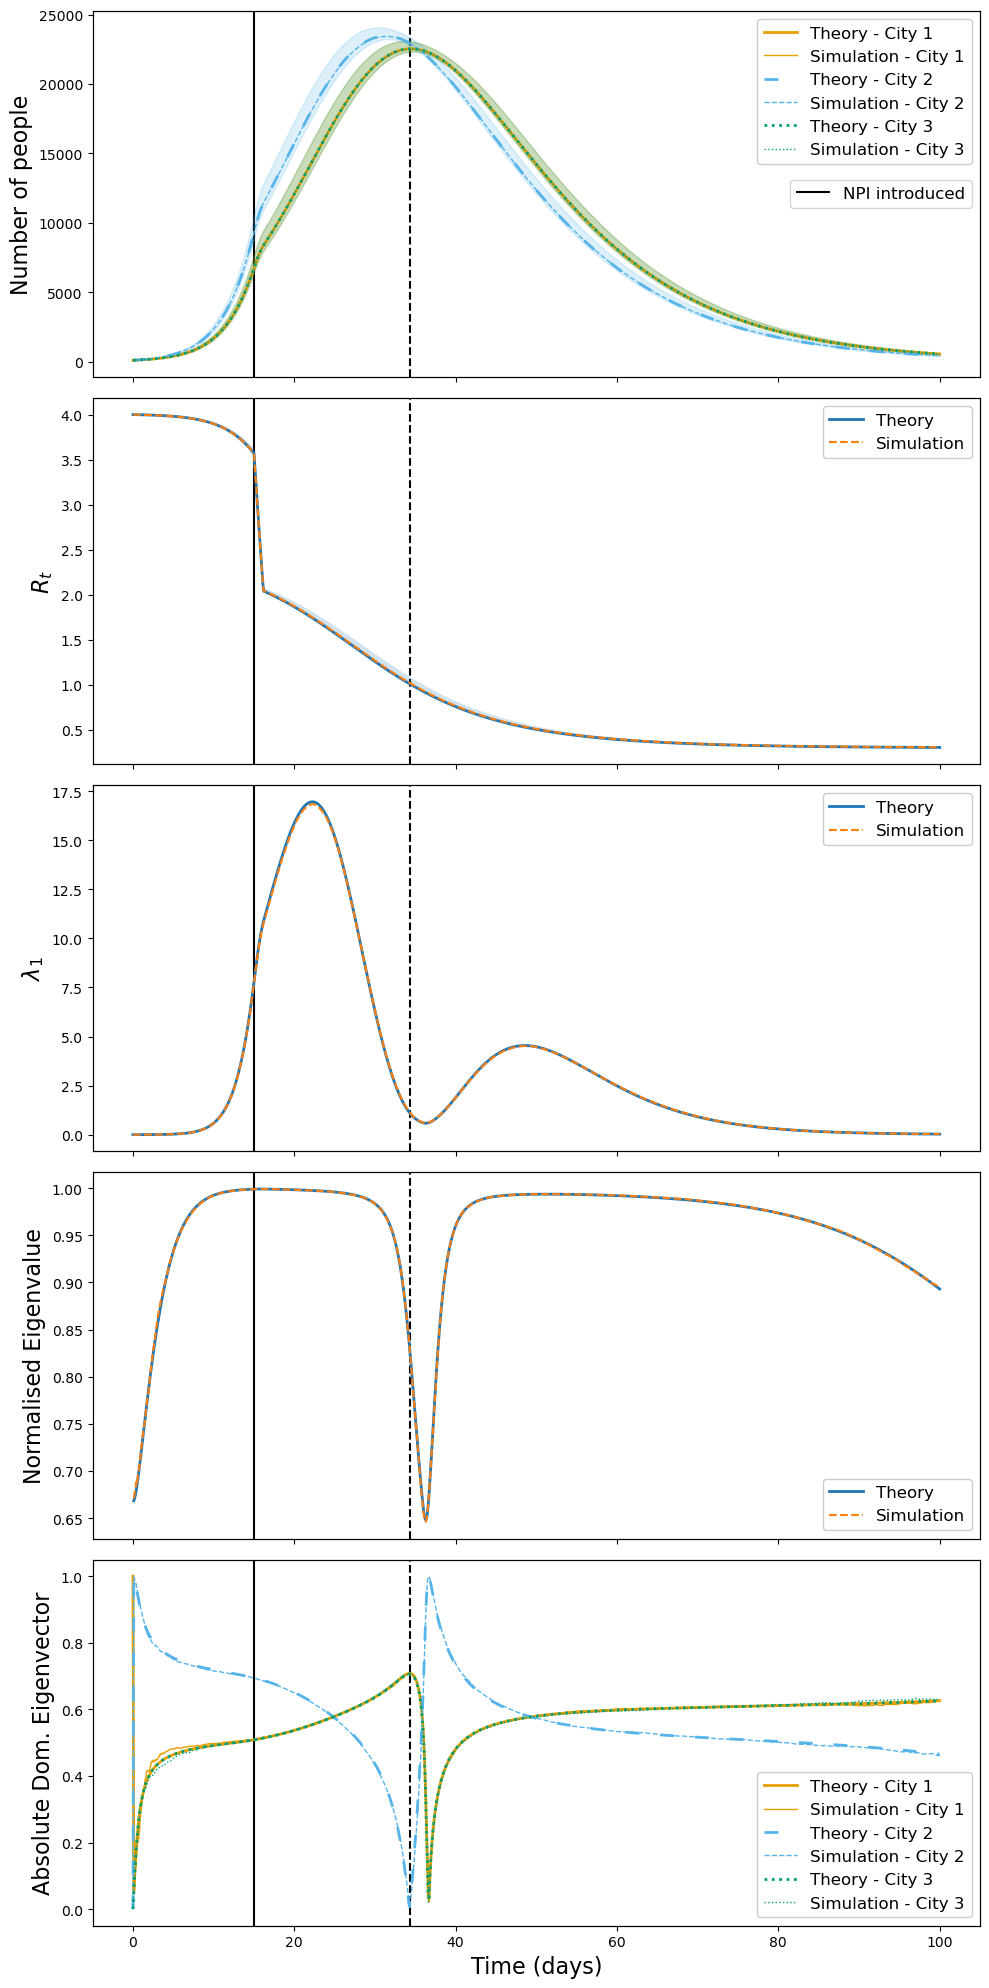

In [19]:
def betat(t):
    if t < 15:
        return beta_matrix
    else:
        temp = np.array([[0,1,0],[1,0,1],[0,1,0]])
        return beta_matrix - 0.1*(t-15)*temp if (beta_matrix - 0.1*(t-15)*temp >= 0).all() else beta_matrix - np.array([[0,b_b,0],[b_b,0,b_b],[0,b_b,0]])

results_between = analyze_epidemic_data('betdec', betat, ts, gamma, mu, N_population, Si, Ii, 0.005)
plot_epidemic_results_single(results_between, ts, 'NPI introduced', npi_time=15, save_path='Figures/bet_city_theory.pdf')

## New variant

0.8532611778611298
1.3303954541400647


/tmp/ipykernel_17822/3158438108.py:7: RuntimeWarning: invalid value encountered in scalar divide
  norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i]))
/tmp/ipykernel_17822/3158438108.py:33: RuntimeWarning: invalid value encountered in scalar divide
  sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/


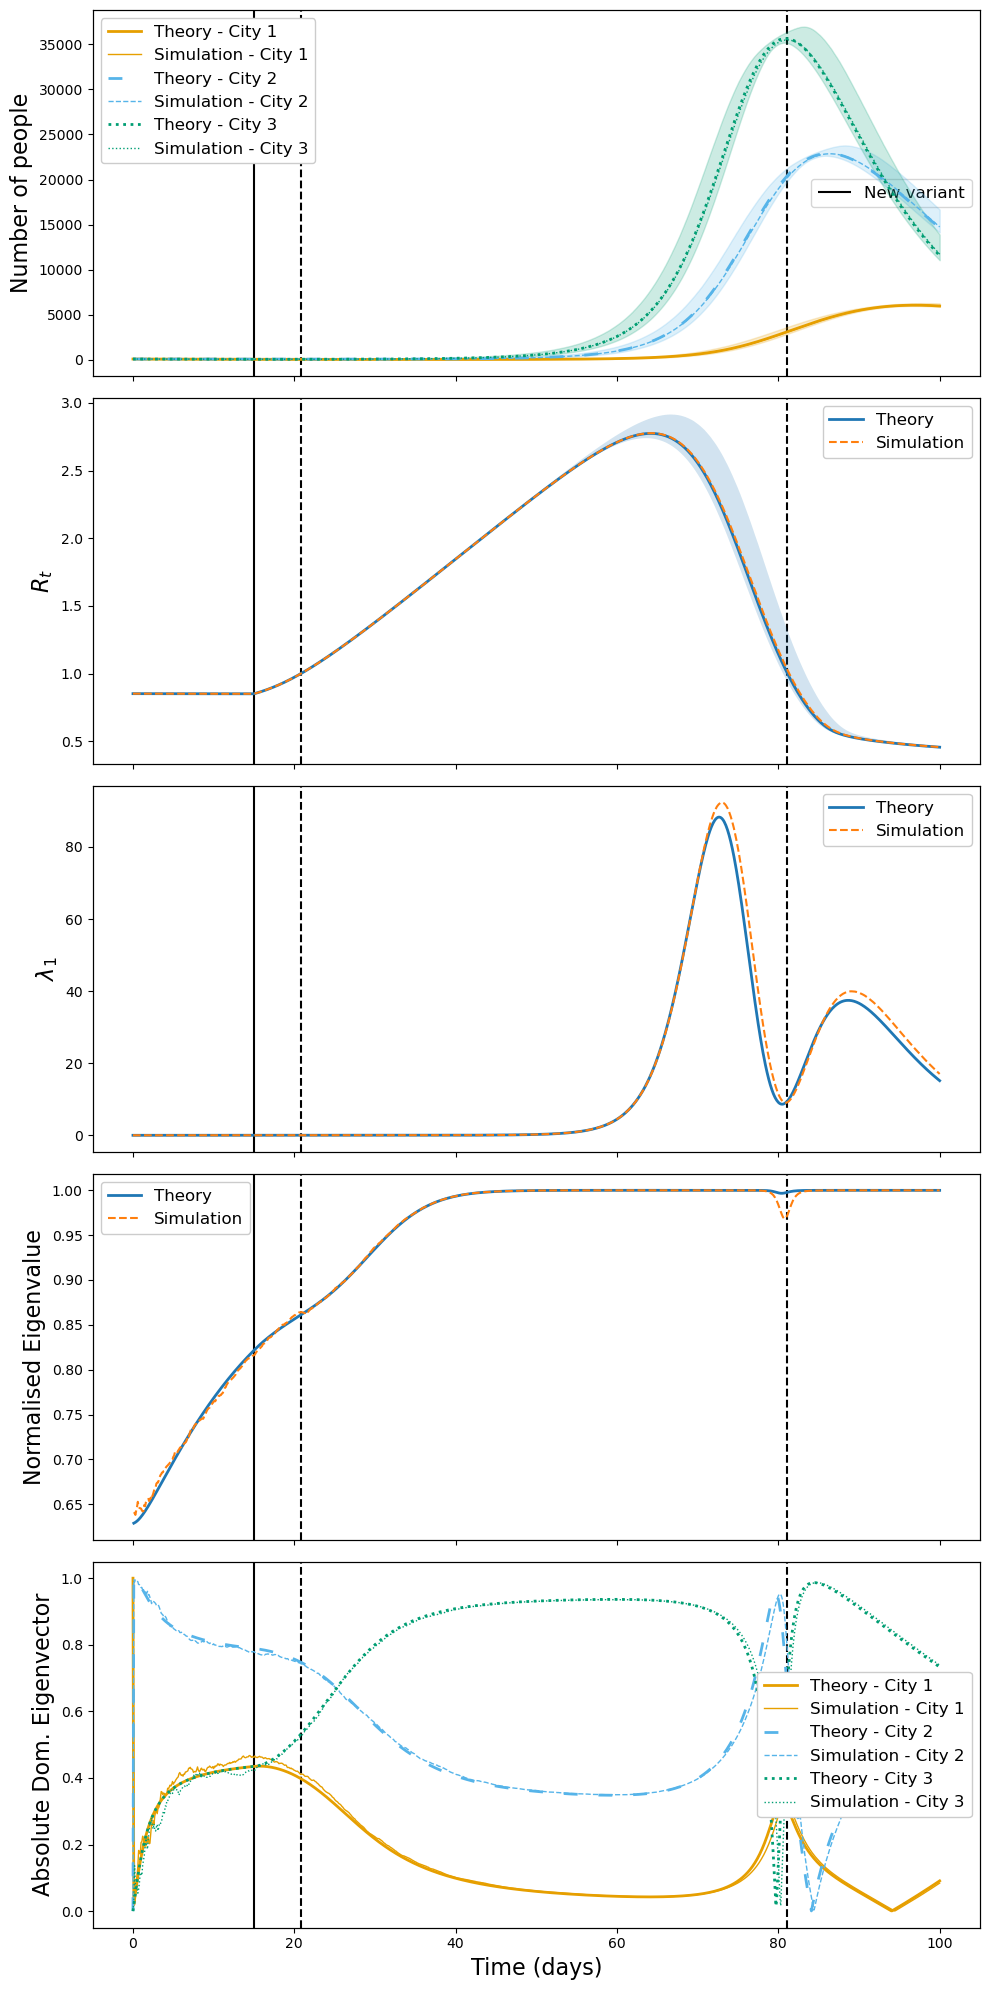

In [20]:
N_cities = 3
T_max = 100
N_population = 100000

Ii = np.array([100,100,100])
Si = N_population - Ii

def betat(t):
    b_w_l = 0.05
    b_b_l = 0.025
    beta_matrix_low = np.array([[b_w_l, b_b_l, 0],
                                [b_b_l, b_w_l, b_b_l],
                                [0,     b_b_l, b_w_l]])
    if t < 15:
        return beta_matrix_low
    else:
        temp = np.array([[0,0,0],
                         [0,0,0.25],
                         [0,0,1]])
        return beta_matrix_low + 0.005*(t-15)*temp

gamma = 0.1
mu = 1/(80*365)
b_w_l = 0.05
b_b_l = 0.025
beta_matrix_low = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,b_b_l],[0,b_b_l,b_w_l]])
print(np.max(np.linalg.eigvals(beta_matrix_low))/(gamma+mu))
beta_matrix_var = np.array([[b_w_l,b_b_l,0],[b_b_l,b_w_l,0.1],[0,b_b_l,0.1]])
print(np.max(np.linalg.eigvals(beta_matrix_var))/(gamma+mu))

results_nv = analyze_epidemic_data('newvar', betat, ts, gamma, mu, N_population, Si, Ii, 0.008)
plot_epidemic_results_single(results_nv, ts, 'New variant', npi_time=15, save_path='Figures/new_var_theory.pdf')

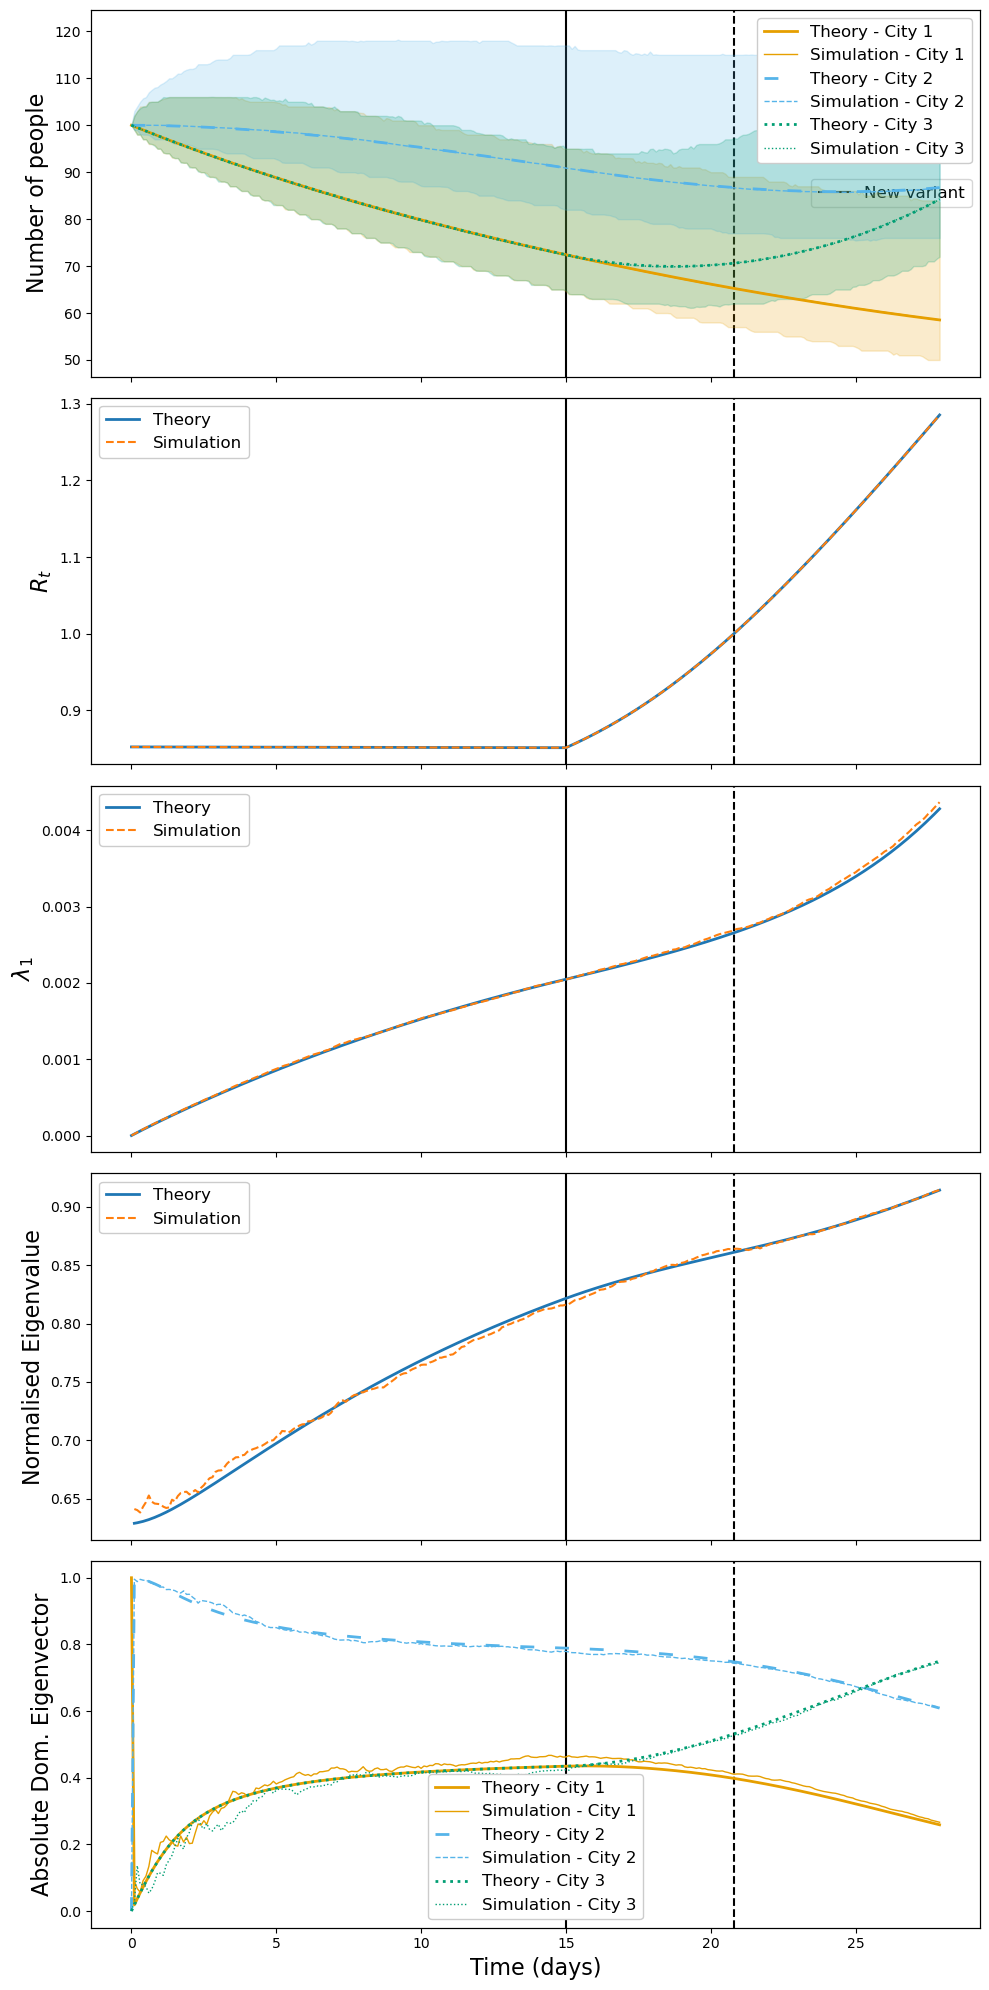

In [ ]:
results_nv["crossings"] = results_nv['crossings'][0]
plot_epidemic_results_single(results_nv, ts[:280], 'New variant', npi_time=15, save_path='Figures/new_var_theory_short.pdf')

## (Re-)Emergence

/tmp/ipykernel_17822/3158438108.py:7: RuntimeWarning: invalid value encountered in scalar divide
  norm_eigvals = [np.max(np.linalg.eigvalsh(cov[i]))/np.linalg.norm(np.linalg.eigvalsh(cov[i]))
/tmp/ipykernel_17822/3158438108.py:33: RuntimeWarning: invalid value encountered in scalar divide
  sim_norm_eigvals = [np.max(np.linalg.eigvalsh(covariances[:,:,i]))/


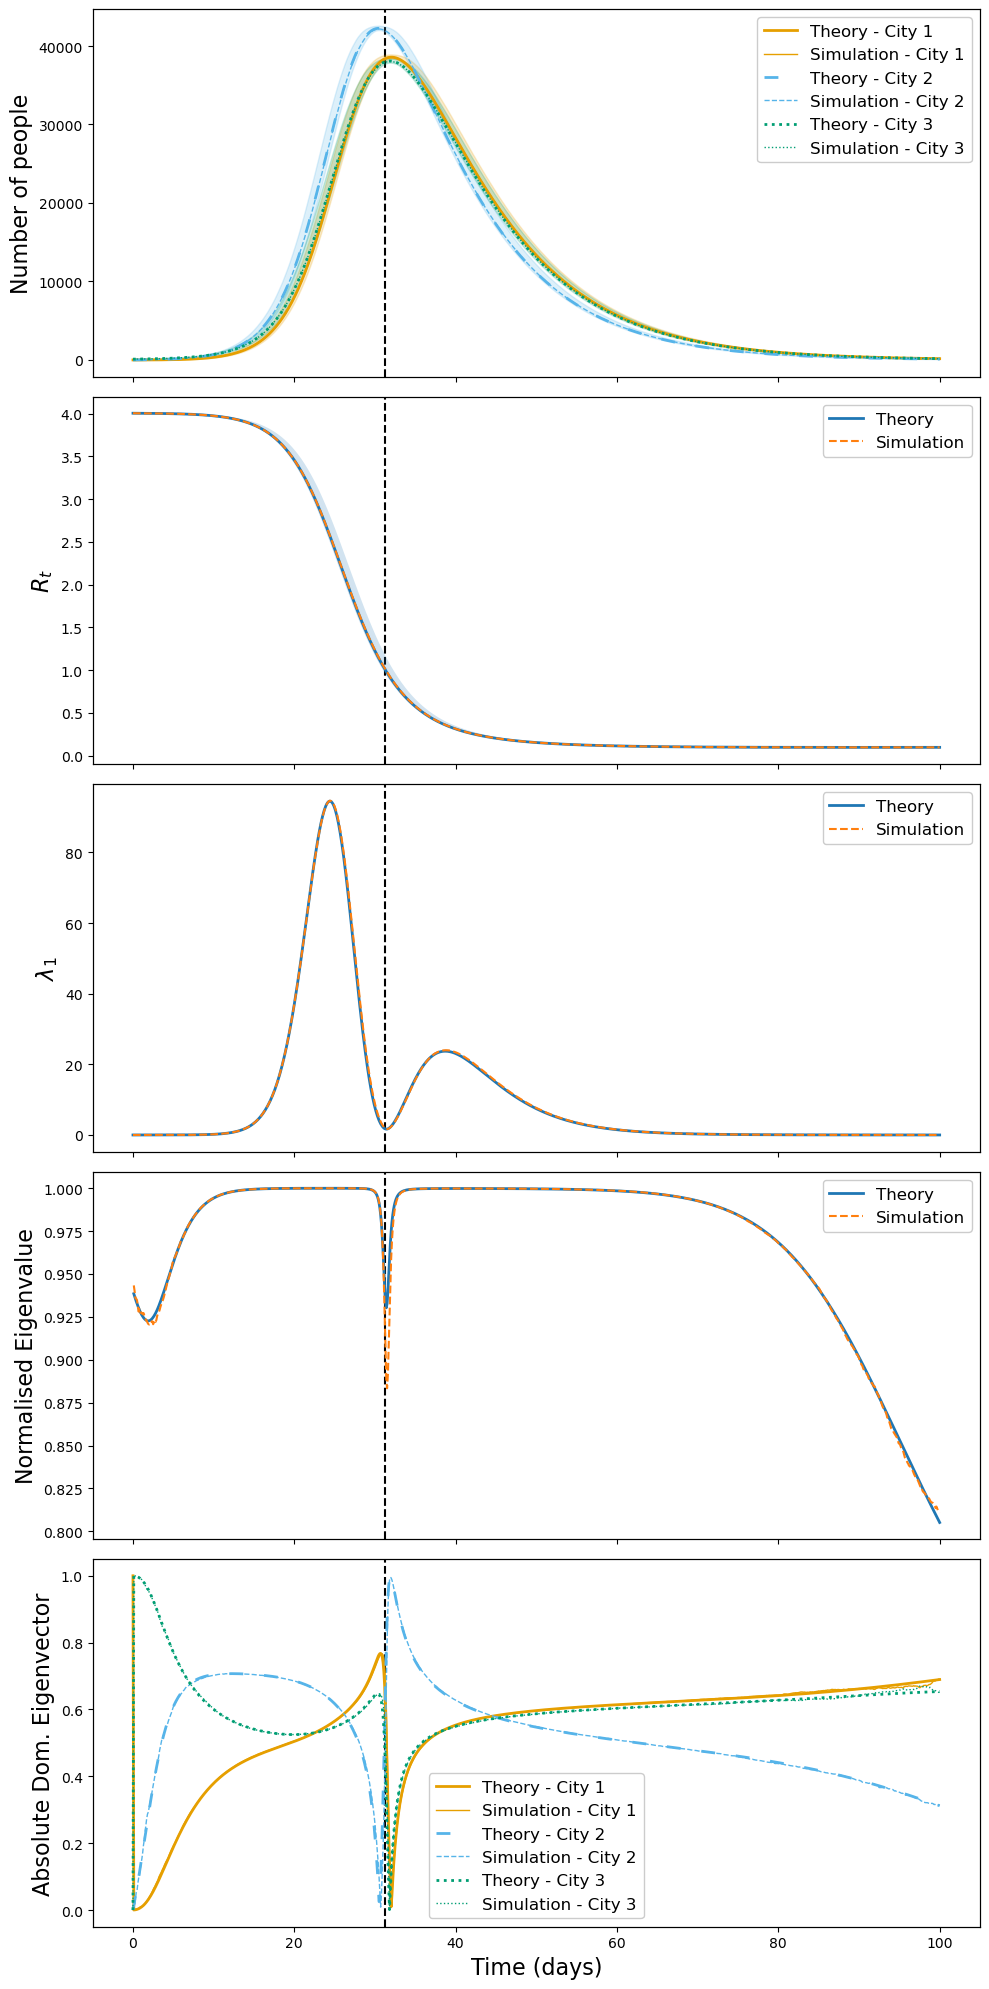

In [27]:
N_cities = 3
T_max = 100
b_w = 0.231
b_b = 0.12
beta_matrix = np.array([[b_w,b_b,0],[b_b,b_w,b_b],[0,b_b,b_w]])
gamma = 0.1
mu = 1/(80*365)
N_population = 100000

Ii = np.array([0,0,100])
Si = N_population - Ii

betat = lambda t: beta_matrix
results_between = analyze_epidemic_data('seed', betat, ts, gamma, mu, N_population, Si, Ii, 0.005)
plot_epidemic_results_single(results_between, ts, 'Single seed', save_path='Figures/seed_theory.pdf')